# Recurrent Neural Networks

## Start with the problem: the same items can mean different things in a different order

Consider two event sequences: `A · B` and `B · A`, where the dot is an unimportant event. Both contain one A, one B, and one dot, but their order differs. A model that only counts events receives the same input for both and cannot tell which happened first.

A recurrent neural network (RNN) processes a sequence step by step while updating a hidden state. The state carries information from earlier steps into later calculations. The same trainable transition is reused at every step; the network is not a separate model for every sequence position.

This lesson works through a two-step RNN completely, including backpropagation through time. A small CPU project then learns whether A appears before B in sequences of different lengths. We compare against a count-only classifier and reserve unseen combinations of length and event positions for evaluation. All data are created locally, with no downloads.

Run the [code companion](21_Recurrent_Neural_Networks.ipynb) to inspect the calculations, training curves, and hidden-state plots. [Gradients and Backpropagation](07_Gradients_and_Backpropagation_Notes.ipynb) introduces the chain rule used here.

## See one transition reused through time

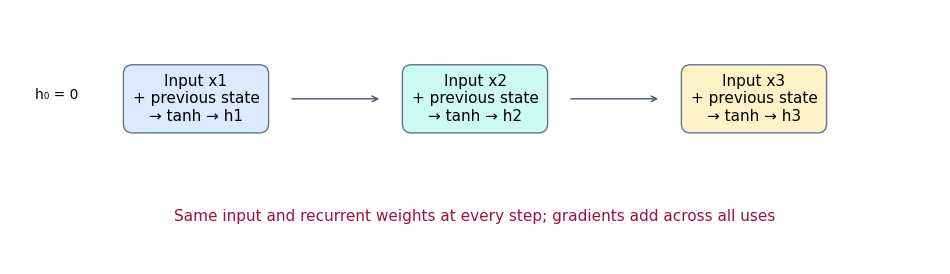

Unrolling draws repeated uses of one transition. It does not create separate parameter sets for the time steps.

## Follow information through a recurrent state

A simple RNN uses

$$h_t=\tanh(W_x x_t+W_h h_{t-1}+b).$$

$x_t$ is the current input, $h_{t-1}$ is the previous hidden state, and $h_t$ is the updated state. $W_x$ controls how the new input contributes; $W_h$ controls how earlier state contributes; $b$ is a shared bias. Tanh maps the combined score into $(-1,1)$ and supplies nonlinearity. The initial state $h_0$ is often zero.

For a one-dimensional example, use input weight $w=1$, recurrent weight $u=0.5$, bias $b=0$, and inputs $[1,0]$.

- Step one: $z_1=1(1)+0.5(0)+0=1$; $h_1=\tanh(1)\approx0.761594$.
- Step two: $z_2=1(0)+0.5(0.761594)+0\approx0.380797$; $h_2\approx0.363399$.

The second input was zero, yet the second state is not zero because the previous state contributes. Reverse the inputs to $[0,1]$: the first state is zero, and the second is $\tanh(1)\approx0.761594$. Both input sequences sum to one, but the final states differ. The repeated nonlinear calculation has retained some order information.

This is not perfect or unlimited memory. Different histories can produce similar states, and useful information may fade. A hidden state is a learned numerical summary, not a literal list of every event seen so far.

## Backpropagate through both uses of the shared parameters

Keep the scalar example and let its final state be the prediction for a teaching target $y=1$. Use half squared error: $L=\tfrac12(h_2-1)^2\approx0.202630$. There is no separate output head in this miniature, so every trainable value is visible.

Start at the prediction: $\partial L/\partial h_2=h_2-1\approx-0.636601$. Since the derivative of tanh is $1-h^2$,

$$\delta_2=\frac{\partial L}{\partial z_2}=(h_2-1)(1-h_2^2)\approx-0.552532.$$

The recurrent connection carries $\delta_2 u$ back to $h_1$. Passing through the first tanh gives

$$\delta_1=\delta_2 u(1-h_1^2)\approx-0.116025.$$

Each parameter was reused at both steps, so add all its contributions:

$$\frac{\partial L}{\partial w}=\delta_1 x_1+\delta_2 x_2=(-0.116025)(1)+(-0.552532)(0)\approx-0.116025,$$

$$\frac{\partial L}{\partial u}=\delta_1 h_0+\delta_2 h_1=0+(-0.552532)(0.761594)\approx-0.420805,$$

$$\frac{\partial L}{\partial b}=\delta_1+\delta_2\approx-0.668556.$$

At SGD rate $0.1$, the simultaneous update gives $w'\approx1.011602$, $u'\approx0.542080$, and $b'\approx0.066856$. Repeating both forward steps gives final state $0.459378$ and loss $0.146136$, below $0.202630$.

This is **backpropagation through time**: unfold the repeated transition into a computation graph and apply the same chain rule as in an ordinary ANN. Time adds repeated uses of shared parameters, not a different calculus. The single bias in this miniature is an effective bias; PyTorch's two stored RNN biases each receive a gradient, so updating both is not the same parameterization as updating this one bias.

## Understand why long-range learning can become difficult

Along the scalar hidden-state path, a derivative across one step contains $u(1-h_t^2)$. Across many steps, such factors multiply. Near zero states, tanh's slope is about one, so $u=0.5$ across ten steps gives $0.5^{10}=0.0009765625$. A much earlier state then has very little local influence on the loss. With $u=1.5$, the corresponding near-zero factor is $1.5^{10}\approx57.665$, illustrating potential growth.

The code constructs exactly zero states so these derivative examples are exact. Away from zero, tanh slopes can shrink the gradient, and a vector RNN uses products of Jacobian matrices rather than one scalar power. Neither example predicts every RNN's behavior.

Gradient clipping can limit an oversized update but cannot reconstruct a gradient that already vanished or ensure useful long memory. Detaching a hidden state between chunks stops gradients across the chunk boundary: it preserves the state's value while limiting the training graph. This is truncated backpropagation, with a deliberate limit on how far credit can propagate.

Our project uses short independent sequences, initializes the hidden state separately for each sequence, and backpropagates through each complete sequence. It does not need truncated backpropagation. LSTMs and GRUs, introduced later, add gates to make information retention and removal more controllable.

## Design a task where counts cannot solve the problem

Each sequence has length six through ten and contains exactly one A, one B, and dots elsewhere. Class zero means A occurs before B; class one means B occurs before A. For every length and pair of event positions, generate both orders. Their token counts are identical but their labels differ.

There are `sum(L × (L−1) / 2 for L in 6..10) = 145` distinct length-and-position templates. Shuffle these templates once and assign 90 to training, 25 to validation, and 30 to test. Each yields two sequences, so the split sizes are 180, 50, and 60. Both orders of a template stay in the same split. Evaluation therefore uses unseen combinations of length and event positions; exact sequences do not overlap.

This synthetic rule is known and could be solved exactly with a short program. The experiment demonstrates learning order-sensitive behavior from examples, not that an RNN is necessary or generally superior. The short lengths also do not establish long-term memory or language understanding.

## Keep batch, time, input, and hidden dimensions separate

With `batch_first=True`, input shape is `(N, T, D)`: number of sequences, padded time length, and input features per step. Here $D=3$ because dot, A, and B have one-hot vectors $[1,0,0]$, $[0,1,0]$, and $[0,0,1]$. This avoids treating token IDs as ordered numeric measurements.

The hidden size is twelve. `nn.RNN` normally returns an output at each time step and a final hidden state. For one unidirectional layer, `h_n` has shape `(1, N, 12)` even with `batch_first=True`; that flag changes input/output sequence axes, not hidden-state axes. Our head maps the final valid hidden state to two logits.

Shorter sequences need padding to form a rectangular batch. A dot is a real input event, whereas padding is absent time. We pad one-hot tensors with the all-zero vector and supply lengths to `pack_padded_sequence`. Packing prevents padding from producing extra recurrent updates. Taking the last padded output blindly would summarize extra steps for short sequences.

The RNN stores input weights $(12,3)$, recurrent weights $(12,12)$, and two bias vectors of length twelve. Its parameter count is $36+144+24=204$. The two-class head adds $2(12+1)=26$, totaling 230. `h_n[-1]` selects the last recurrent layer's state, not the last example. For a bidirectional or multilayer model, the hidden-state layout requires additional care.

## Fit a count-only baseline before training the RNN

Summing one-hot inputs over time gives counts of dot, A, and B. Each paired template produces the same counts for opposite labels, so no deterministic classifier of these counts can distinguish both. Every split is balanced within each count pattern, limiting count-only accuracy to 50% here.

We fit logistic regression to these count features using training labels only. This is intentionally a representation-limited baseline that makes the role of order visible, not the strongest possible sequence competitor. A position-aware feed-forward model or an explicit program could use information that this baseline discards.

The RNN instead sees each event in temporal order and applies a recurrent state update. Whether training learns the desired rule is measured on separate templates, not assumed from its architecture.

## Train on full sequences and select with validation loss

For each minibatch, initialize the hidden state to zero, compute logits from final valid states, and compare them with order labels using cross-entropy. Backpropagation sends that classification signal through all valid steps and sums gradients into the shared recurrent parameters. Adam then updates those parameters.

The hidden state is reset for every independent sequence, which PyTorch does when no initial state is supplied. Carrying state from one shuffled training example into an unrelated one would leak irrelevant history. Stateful processing is appropriate only when the intended data stream and ordering require it.

We use a fixed 80 epochs and batch size 32. With 180 training sequences, there are six updates per epoch, or 480 total. We clip the gradient norm to one after backward and before the optimizer step; the raw norm is recorded to show when clipping was applied. Clipping addresses oversized gradients, not missing long-range information.

After each epoch, evaluate both training and validation loss with fixed weights and no gradient recording. Save a deep copy of the lowest-validation-loss checkpoint, including the initial state, and reload it before test evaluation. Test templates do not choose the training schedule or checkpoint.

## Read sequence-learning progress

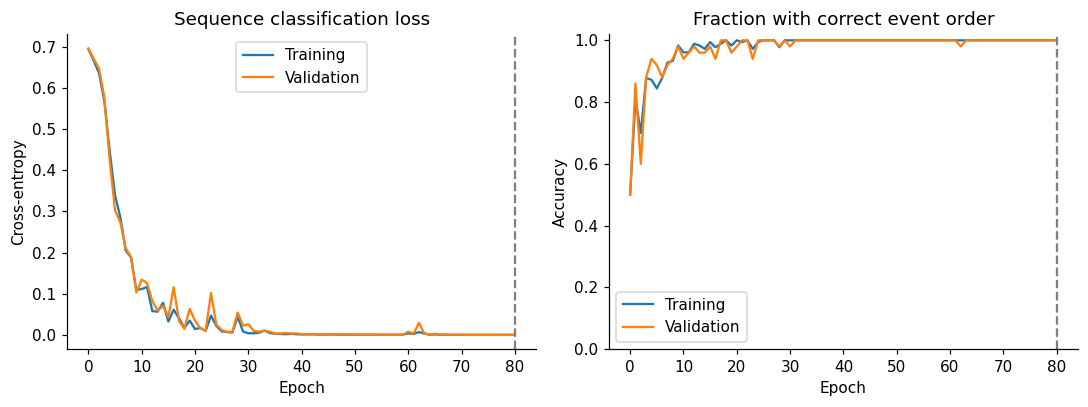

Training and validation evaluate fixed model states after each epoch. The vertical line marks the validation-selected checkpoint.

## Evaluate unseen position templates once

We evaluate the chosen RNN and fixed count baseline on the same 60 test sequences. Each represents one of 30 unseen length-and-position templates in both event orders. Accuracy measures correct order decisions; cross-entropy measures assigned probability on the true order. Both methods have class index zero for A before B and one for B before A.

A good RNN result would show learning within this short, controlled task. It would not demonstrate robustness to longer sequences, multiple A/B events, missing events, or different alphabets. The two examples from each template are related, so the 60 sequences should not be treated as 60 fully independent templates in uncertainty estimates.

We do not retrain after examining the test comparison. The task has a simple exact symbolic solution; learning it here explains how a recurrent ANN can use order when a representation based only on counts cannot.

## Compare order predictions

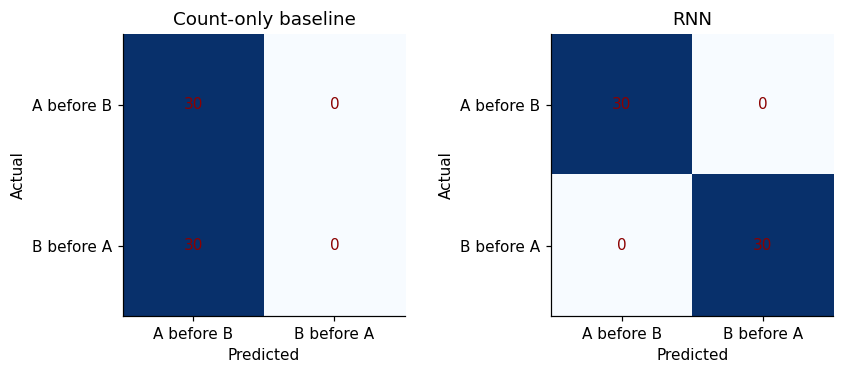

Rows are true orders and columns are predictions. The count-only baseline discards order; the RNN processes events sequentially.

## Trace a trained state one step at a time

For one fixed test sequence, explicitly repeat the learned matrix calculation:

$$h_t=\tanh(x_t W_{ih}^T+h_{t-1}W_{hh}^T+b_{ih}+b_{hh}).$$

The code compares every twelve-value hidden state with `nn.RNN`, then computes the final logits as $h_T W_{head}^T+b_{head}$ and verifies they match the cached test prediction. This is the scalar hand example expanded to a learned vector state.

A heatmap shows how each hidden coordinate changes as events arrive. Individual coordinates do not necessarily mean “A seen” or “B seen”; information may be distributed across several coordinates. The plot shows the computation, not proof of a human-like memory mechanism.

Many-to-one prediction uses a final state for a sequence label, as we do here. A many-to-many model can attach outputs to each step, for example for sequence labeling or next-event prediction. Forecasting requires causal inputs and chronological evaluation; a random split of overlapping time windows can leak future information. Those are different data-design requirements from our independent generated sequences.

## Inspect the learned state trajectory

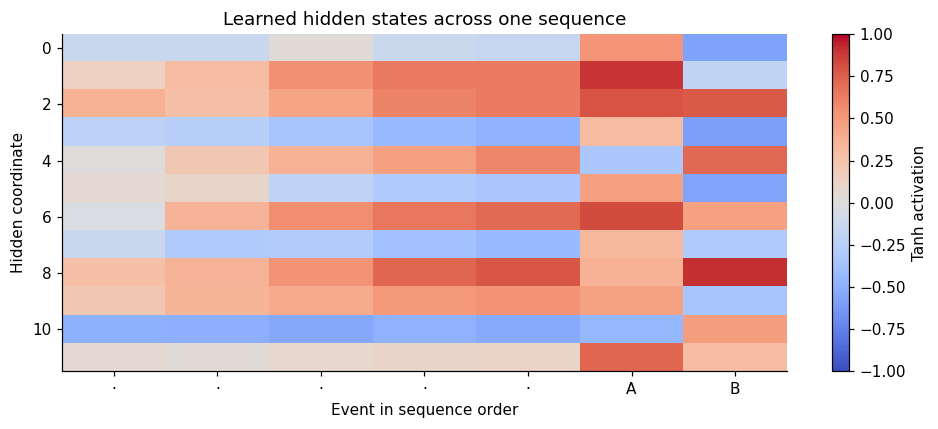

Each row is a hidden coordinate; columns follow one held-out sequence. The manual matrix recurrence matches all plotted states.

## Save the vocabulary, class meanings, and state convention

A saved RNN needs the order of input features, not only its weights. The feature vector `[0,1,0]` means A only because the vocabulary is dot, A, B. The output indices similarly need the mapping A-before-B, B-before-A. Hidden size, activation, and directionality define the architecture.

The prediction recipe pads valid one-hot events, carries their lengths, packs them, and initializes the hidden state to zero for each independent sequence. The temporary checkpoint records these conventions. Restoring it into a fresh model must reproduce the same probabilities. No optimizer state is required for inference.

A streaming system might intentionally retain a state across chunks, but its reset and detachment rules must match the task. Carrying an old state into a new independent sequence would change its prediction. The demonstrated interface does not claim to support continuous stateful streams.

## Read the saved reference run

All 11 code cells and embedded assertions passed in a fresh in-process CPU kernel. The 230-parameter RNN made 480 updates. Validation selected epoch 80 with cross-entropy 0.000210. Gradient clipping was triggered on 103 updates; the largest raw norm was 10.330697.

| Model | Correct on test | Accuracy | Cross-entropy |
| --- | --- | --- | --- |
| Count-only baseline | 30/60 | 50.0% | 0.693147 |
| RNN | 60/60 | 100.0% | 0.000295 |

The test set consists of both orders from 30 unseen length-and-position templates. The result measures the specified short-sequence task, not longer-range memory or a comparison with every possible sequence model. Manual recurrence and gradient calculations, padding invariance, per-sequence batching, and save/restore checks all passed.

## What the recurrent computation contributes

The hidden state lets the ANN combine a current event with information from earlier events. Reusing the same transition supports variable-length sequences without allocating new weights for each position. Backpropagation through time teaches shared parameters how early events should influence later predictions.

The synthetic experiment isolates order sensitivity and checks padding, shared gradients, state initialization, and model reuse. It does not establish long-range memory or a universal advantage over feed-forward models, convolution over sequences, attention, or an explicit rule.

Plain RNNs are an important foundation, but repeated Jacobian products can make distant learning difficult and sequential computation limits parallelism across time. Gated recurrent networks and attention address different parts of these limitations. The useful starting point is understanding exactly what is calculated and what the evidence supports.